# Business problem

A marketing agency manages advertising campaigns for multiple clients and aims to maximize the Return on Investment (ROI) from digital advertising. The agency recently launched two advertising campaigns on different platforms: Facebook Ads and Google Ads.

Although both campaigns are generating impressions, clicks, and conversions, it is unclear which platform delivers better performance and cost efficiency. Since advertising budgets are limited, the agency needs to determine which platform provides higher engagement and better conversion outcomes.

The key challenge is to compare the effectiveness of the two advertising campaigns by analyzing performance metrics such as click-through rate (CTR), conversion rate, advertising cost, and return on investment.

The insights from this analysis will help the agency optimize budget allocation, focus on the more effective advertising platform, and improve overall campaign performance for their clients.

# Dataset description



**Rows:** 1000  
**Columns:** 17  
**Purpose:** Ideal for marketing professionals and data enthusiasts interested in A/B testing, performance comparisons, and cost analysis between Facebook Ads and AdWords.  

**Source:** Mock data generated from scratch using Mockaroo.

This structured dataset offers a comprehensive foundation for exploring advertising performance metrics and gaining actionable insights into campaign effectiveness.

# Dataset Schema

| Column Name              | Data Type | Description |
|--------------------------|-----------|-------------|
| `date_of_campaign`       | datetime  | The date of each campaign, ranging from 2021 to 2024. |
| `facebook_ad_campaign`   | object    | The name of the Facebook ad campaign. |
| `facebook_ad_views`      | integer   | The number of people who viewed the Facebook ad. |
| `facebook_ad_clicks`     | integer   | The number of people who clicked the Facebook ad after viewing it. |
| `facebook_ad_conversions`| integer   | The number of people who became customers after clicking the Facebook ad. |
| `facebook_cost_per_ad`   | integer   | The cost (in USD $) of running a Facebook ad. |
| `facebook_ctr`           | float     | Facebook Click-Through Rate in % (CTR): `(facebook_ad_clicks / facebook_ad_views) × 100` |
| `facebook_conversion_rate`| float   | Facebook conversion rate in %: `(facebook_ad_conversions / facebook_ad_clicks) × 100` |
| `facebook_cost_per_click`| float     | Cost per click for Facebook ads (in USD $): `(facebook_cost_per_ad / facebook_ad_clicks)` |
| `adword_ad_campaign`     | object    | The name of the AdWords campaign. |
| `adword_ad_views`        | integer   | The number of people who viewed the AdWords ad. |
| `adword_ad_clicks`       | integer   | The number of people who clicked the AdWords ad after viewing it. |
| `adword_ad_conversions`  | integer   | The number of people who became customers after clicking the AdWords ad. |
| `adword_cost_per_ad`     | integer   | The cost (in USD) of running an AdWords ad. |
| `adword_ctr`             | float     | AdWords Click-Through Rate in % (CTR): `(adword_ad_clicks / adword_ad_views) × 100` |
| `adword_conversion_rate` | float     | AdWords conversion rate in %: `(adword_ad_conversions / adword_ad_clicks) × 100` |
| `adword_cost_per_click`  | float     | Cost per click for AdWords ads (in USD $): `(adword_cost_per_ad / adword_ad_clicks)` |

# Importing libraries and dataset


In [1]:
!pip install scikit-learn statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint

In [3]:
df = pd.read_csv("A_B_testing_dataset.csv")

# Exploring the data set and Feature engineering

In [4]:
# Data overview
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad
0,22-12-2021,FACEBOOK AD,3172,62,14,141,ADWORD AD,5754,64,9,177
1,24-12-2021,FACEBOOK AD,3211,38,9,186,ADWORD AD,4954,73,6,54
2,25-12-2021,FACEBOOK AD,1936,53,15,66,ADWORD AD,4702,38,9,187
3,25-12-2021,FACEBOOK AD,1194,45,9,71,ADWORD AD,3718,58,3,161
4,26-12-2021,FACEBOOK AD,2479,44,12,174,ADWORD AD,5562,63,4,162


In [5]:
# Count of rows and columns
df.shape

(1000, 11)

In [6]:
# Data types
df.dtypes

date_of_campaign           object
facebook_ad_campaign       object
facebook_ad_views           int64
facebook_ad_clicks          int64
facebook_ad_conversions     int64
facebook_cost_per_ad        int64
adword_ad_campaign         object
adword_ad_views             int64
adword_ad_clicks            int64
adword_ad_conversions       int64
adword_cost_per_ad          int64
dtype: object

In [7]:
# Descriptive stats of the campaign
df.describe().T

,count,mean,std,min,25%,50%,75%,max
facebook_ad_views,1000.0,2152.031,661.982166,1050.0,1600.25,2123.5,2706.25,3320.0
facebook_ad_clicks,1000.0,44.196,16.833328,15.0,30.00,44.5,58.00,73.0
facebook_ad_conversions,1000.0,11.975,4.298471,5.0,8.00,12.0,16.00,19.0
facebook_cost_per_ad,1000.0,156.610,54.918904,60.0,110.00,156.0,205.00,250.0
adword_ad_views,1000.0,4771.438,598.647684,3715.0,4258.25,4808.5,5300.75,5754.0
adword_ad_clicks,1000.0,60.128,17.047822,31.0,45.00,60.0,75.00,89.0
adword_ad_conversions,1000.0,5.933,2.011606,3.0,4.00,6.0,8.00,9.0
adword_cost_per_ad,1000.0,124.741,43.809053,50.0,86.00,124.0,163.00,200.0


In [8]:
#facebook click through rate 
df['facebook_ctr'] = round((df['facebook_ad_clicks']/df['facebook_ad_views'])*100, 2)

In [9]:
#facebook Conversion rate
df['facebook_conversion_rate'] = round((df['facebook_ad_conversions']/df['facebook_ad_clicks'])*100,2)

In [10]:
# Facebook cost per click 
df['facebook_cost_per_click'] = round((df['facebook_cost_per_ad']/df['facebook_ad_clicks']),2)

In [11]:
#adword click through rate 
df['adword_ctr'] = round((df['adword_ad_clicks']/df['adword_ad_views'])*100,2)

In [12]:
#adword Conversion rate
df['adword_conversion_rate'] = round((df['adword_ad_conversions']/df['adword_ad_clicks'])*100,2)

In [13]:
#adword cost per click 
df['adword_cost_per_click'] = round((df['adword_cost_per_ad']/df['adword_ad_clicks']),2)

In [14]:
df['date_of_campaign'] = pd.to_datetime(df['date_of_campaign'], format='%d-%m-%Y')

In [15]:
# Updated Count of rows and columns 
df.shape

(1000, 17)

In [16]:
# Updated datatypes
df.dtypes

date_of_campaign            datetime64[ns]
facebook_ad_campaign                object
facebook_ad_views                    int64
facebook_ad_clicks                   int64
facebook_ad_conversions              int64
facebook_cost_per_ad                 int64
adword_ad_campaign                  object
adword_ad_views                      int64
adword_ad_clicks                     int64
adword_ad_conversions                int64
adword_cost_per_ad                   int64
facebook_ctr                       float64
facebook_conversion_rate           float64
facebook_cost_per_click            float64
adword_ctr                         float64
adword_conversion_rate             float64
adword_cost_per_click              float64
dtype: object

In [17]:
# Updated Data overview 
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,ADWORD AD,5754,64,9,177,1.95,22.58,2.27,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,ADWORD AD,4954,73,6,54,1.18,23.68,4.89,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,ADWORD AD,4702,38,9,187,2.74,28.30,1.25,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,ADWORD AD,3718,58,3,161,3.77,20.00,1.58,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,ADWORD AD,5562,63,4,162,1.77,27.27,3.95,1.13,6.35,2.57


In [18]:
# Updated Descriptive stats of the campaign
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_of_campaign,1000,2023-07-04 07:13:26.399999744,2021-12-22 00:00:00,2022-10-07 18:00:00,2023-07-20 12:00:00,2024-03-24 00:00:00,2024-12-20 00:00:00,NaN
facebook_ad_views,1000.0,2152.031,1050.0,1600.25,2123.5,2706.25,3320.0,661.982166
facebook_ad_clicks,1000.0,44.196,15.0,30.0,44.5,58.0,73.0,16.833328
facebook_ad_conversions,1000.0,11.975,5.0,8.0,12.0,16.0,19.0,4.298471
facebook_cost_per_ad,1000.0,156.61,60.0,110.0,156.0,205.0,250.0,54.918904
adword_ad_views,1000.0,4771.438,3715.0,4258.25,4808.5,5300.75,5754.0,598.647684
adword_ad_clicks,1000.0,60.128,31.0,45.0,60.0,75.0,89.0,17.047822
adword_ad_conversions,1000.0,5.933,3.0,4.0,6.0,8.0,9.0,2.011606
adword_cost_per_ad,1000.0,124.741,50.0,86.0,124.0,163.0,200.0,43.809053
facebook_ctr,1000.0,2.28316,0.49,1.3675,2.07,2.9225,6.86,1.2067


# Comparing campaign performance 

<Axes: title={'center': 'adword Ad Conversion'}, xlabel='adword_ad_conversions', ylabel='Count'>

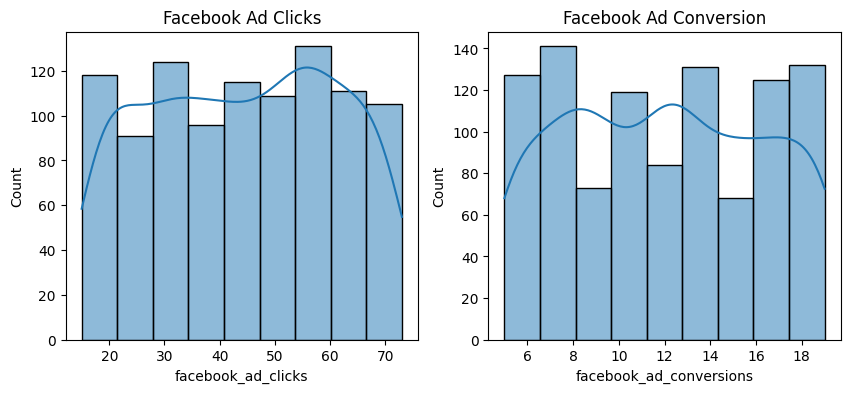

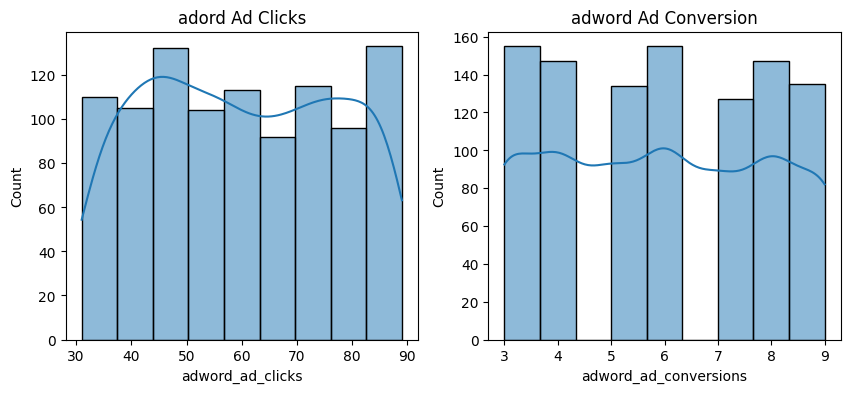

In [19]:
# Distributions of clicks and conversion
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['facebook_ad_clicks'], bins=9, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title('Facebook Ad Conversion')
sns.histplot(df['facebook_ad_conversions'], bins=9, edgecolor = 'k', kde = True)

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.title('adord Ad Clicks')
sns.histplot(df['adword_ad_clicks'], bins=9, edgecolor = 'k', kde = True)
plt.subplot(1,2,2)
plt.title('adword Ad Conversion')
sns.histplot(df['adword_ad_conversions'], bins=9, edgecolor = 'k', kde = True)




All the histograms are showing somewhat symmetrical shape the symmetrical shape should just that the number of Clicks and conversion is relatively evenly distributed in other words there are not many clicks or conversion That are outliers on either higher end or at lower end 

#### How frequently do we observe days with high number of conversion compared to the days with low number of conversions

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DEFINE THE CATEGORIZATION FUNCTION ---
def create_conversion_category(conversion_col):
    category = []
    for conversion in conversion_col:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6 - 10')
        elif 11 <= conversion < 16:
            # Note: Updated label to '11 - 15' to match your logic (11 <= x < 16)
            category.append('10 - 15')
        else:
            category.append('greater than 15')
    return category

# --- 2. APPLY CATEGORIES TO DATAFRAME ---
df['facebook_conversion_category'] = create_conversion_category(df['facebook_ad_conversions'])
df['adword_conversion_category'] = create_conversion_category(df['adword_ad_conversions'])



In [21]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ctr,adword_conversion_rate,adword_cost_per_click,facebook_conversion_category,adword_conversion_category
0,2021-12-22,FACEBOOK AD,3172,62,14,141,ADWORD AD,5754,64,9,177,1.95,22.58,2.27,1.11,14.06,2.77,10 - 15,6 - 10
1,2021-12-24,FACEBOOK AD,3211,38,9,186,ADWORD AD,4954,73,6,54,1.18,23.68,4.89,1.47,8.22,0.74,6 - 10,6 - 10
2,2021-12-25,FACEBOOK AD,1936,53,15,66,ADWORD AD,4702,38,9,187,2.74,28.30,1.25,0.81,23.68,4.92,10 - 15,6 - 10
3,2021-12-25,FACEBOOK AD,1194,45,9,71,ADWORD AD,3718,58,3,161,3.77,20.00,1.58,1.56,5.17,2.78,6 - 10,less than 6
4,2021-12-26,FACEBOOK AD,2479,44,12,174,ADWORD AD,5562,63,4,162,1.77,27.27,3.95,1.13,6.35,2.57,10 - 15,less than 6


In [22]:
# --- 3. PREPARE FREQUENCY TABLES ---
# We use value_counts() to count how many days fall into each category
facebook = pd.DataFrame(df['facebook_conversion_category'].value_counts()).reset_index()
facebook.columns = ['category', 'fb_count'] # Clear naming

adword = pd.DataFrame(df['adword_conversion_category'].value_counts()).reset_index()
adword.columns = ['category', 'ad_count'] # Clear naming



In [23]:
# --- 4. MERGE AND CLEAN DATA ---
# Merge both platforms on the category name
category_df = pd.merge(facebook, adword, on='category', how='outer').fillna(0)

# Manually sort the rows so the X-axis reads logically (low to high)
# Adjust the list [3, 1, 0, 2] if your specific data order is different
category_df = category_df.iloc[[3, 1, 0, 2]]



In [24]:
category_df

,category,fb_count,ad_count
3,less than 6,65,436.0
1,6 - 10,337,564.0
0,10 - 15,341,0.0
2,greater than 15,257,0.0


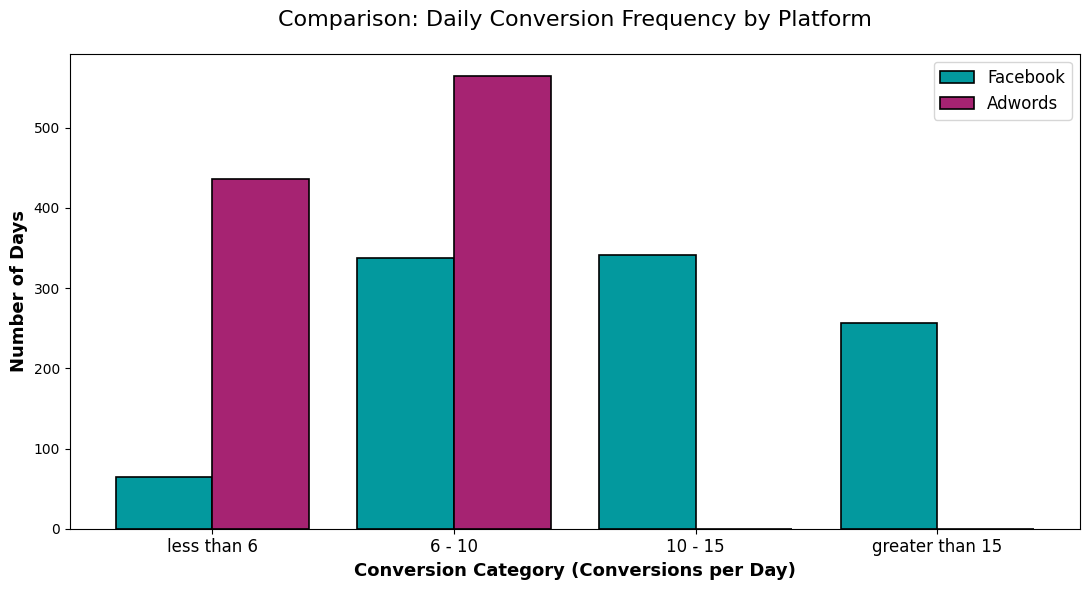

In [25]:
# --- 5. VISUALIZATION ---
x_axis = np.arange(len(category_df))
plt.figure(figsize=(11, 6))
# Plot Facebook Bars
plt.bar(x_axis - 0.2, category_df['fb_count'], 0.4, 
        label='Facebook', color="#03999E", linewidth=1.2, edgecolor='black')
# Plot Adword Bars (FIXED: Now points to ad_count instead of duplicate fb_count)
plt.bar(x_axis + 0.2, category_df['ad_count'], 0.4, 
        label='Adwords', color="#A62372", linewidth=1.2, edgecolor='black')
# Formatting
plt.xticks(x_axis, category_df['category'], fontsize=12)
plt.yticks(fontsize=10)
plt.xlabel("Conversion Category (Conversions per Day)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Days", fontsize=13, fontweight='bold')
plt.title("Comparison: Daily Conversion Frequency by Platform", fontsize=16, pad=20)
plt.legend(fontsize=12)

# Optional: Add a light grid for better readability
plt.tight_layout()
plt.show()

- the data suggest that the Facebook had more frequent higher conversion days than the Adwords which either had very low conversation rates less than six or 6 to 10

- There is a significant variance in the number of Higher conversion days between two different campaigns

- The absence of Any days With conversion between 10 to 15 And more than 15 in Adwords indicates a need to review what strategies were changed Or what external factors could have influenced these numbers 

#### Do more clicks on the ad really lead to more sales

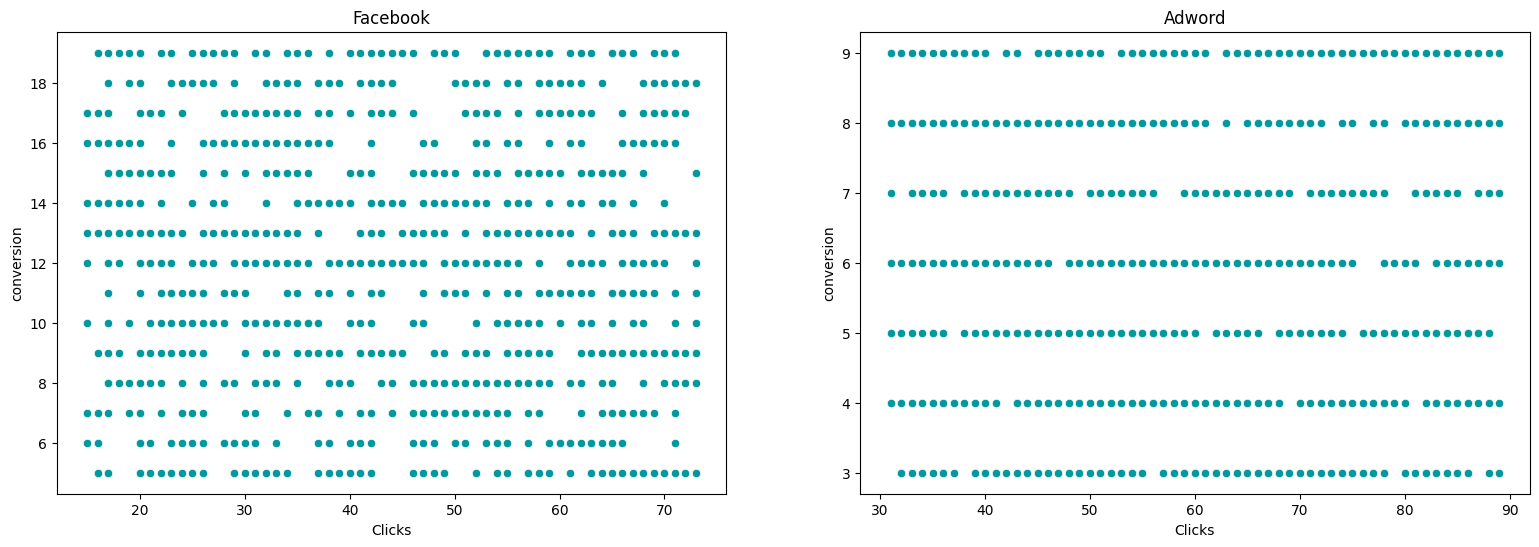

In [26]:
plt.figure(figsize=(19,6))
plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(x = df['facebook_ad_clicks'], y=df['facebook_ad_conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('conversion')

plt.subplot(1,2,2)
plt.title('Adword')
sns.scatterplot(x = df['adword_ad_clicks'], y=df['adword_ad_conversions'], color = '#03989E')
plt.xlabel('Clicks')
plt.ylabel('conversion')

plt.show()


In [27]:
facebookcorrelation = df[['facebook_ad_conversions','facebook_ad_clicks']].corr()
facebookcorrelation

,facebook_ad_conversions,facebook_ad_clicks
facebook_ad_conversions,1.000000,-0.005009
facebook_ad_clicks,-0.005009,1.000000


In [28]:
adwordcorrelation = df[['adword_ad_conversions','adword_ad_clicks']].corr()
adwordcorrelation

,adword_ad_conversions,adword_ad_clicks
adword_ad_conversions,1.000000,0.004162
adword_ad_clicks,0.004162,1.000000


In [29]:
print('Correlation Coeff \n-----------------------------------')
print('Facebook :', round(facebookcorrelation.values[0,1],2))
print('Adword :', round(adwordcorrelation.values[0,1],2))

Correlation Coeff 
-----------------------------------
Facebook : -0.01
Adword : 0.0


- No Correlation: The statistical relationship is 0.0, meaning there is no link between the two. Increasing clicks does not result in a predictable increase in sales.

- Ad Fatigue (Facebook): The negative (-0.01) correlation on Facebook suggests that "over-advertising" might be happening. Seeing the ad too many times might be turning customers away rather than attracting them.

- Search Intent Limit (Adwords): The flat 0.0 on Adwords suggests that while the traffic is consistent, the "pool" of high-intent buyers is small. Adding more clicks just brings in "window shoppers" who don't convert.

- Bottleneck elsewhere: The problem isn't the number of people clicking; the problem is what happens after they click. This suggests the issue lies in the pricing, the landing page, or the checkout process.

### **Hypothesis testing**

**Hypothesis**: Advertising on Facebook will result a great number of conversion compared to the advertising on Adword

**Null hypothesis**: There is no difference in the number of conversion between Facebook and Adwords, Or the number of conversion from adword is greater than or equal to those from Facebook.

**Alternate hypothesis**: Richard Clarke the number of conversions from Facebook is greater than the number of conversions from Adwords 

H1 facebook > adwords

In [30]:
import scipy.stats as st  # Ensure this is imported

# 1. Print Mean Conversions
print("Mean Conversion")
print("---------------")
print('Facebook :', round(df['facebook_ad_conversions'].mean(), 2))
print('Adword   :', round(df['adword_ad_conversions'].mean(), 2))

# 2. Perform Welch's T-Test (equal_var=False is safer for marketing data)
t_stats, p_value = st.ttest_ind(a=df['facebook_ad_conversions'], 
                                b=df['adword_ad_conversions'], 
                                equal_var=False)

# 3. Print Results with clean formatting
print(f'\nT-Statistic: {t_stats:.4f}')
print(f'p-value    : {p_value:.4e}') # Using scientific notation for very small p-values

# 4. Hypothesis Testing Logic
# Null Hypothesis (H0): There is no difference between Facebook and Adword conversions.
# Alternative Hypothesis (H1): There is a significant difference.

if p_value < 0.05:
    print("\nResult: The p-value is less than the 0.05 significance level.")
    print("Action: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant difference between the two platforms.")
else:
    print("\nResult: The p-value is greater than the 0.05 significance level.")
    print("Action: Fail to reject (Accept) the Null Hypothesis.")
    print("Conclusion: The difference between the platforms is likely due to chance.")

Mean Conversion
---------------
Facebook : 11.98
Adword   : 5.93

T-Statistic: 40.2591
p-value    : 6.8864e-237

Result: The p-value is less than the 0.05 significance level.
Action: Reject the Null Hypothesis.
Conclusion: There is a statistically significant difference between the two platforms.


- Statistical Dominance: Facebook’s mean conversion (11.98) is significantly higher than Adword’s (5.93).

- Clear Superiority: With a p-value of near-zero ($< 0.05$), we reject the Null Hypothesis. This proves the performance difference is real and repeatable, not a random fluke.

- Reliability: The high T-statistic (40.25) indicates that Facebook isn't just "sometimes" better; it consistently outperforms Adword across the entire dataset.

- usiness Impact: Facebook is the primary driver of volume for the business. While Adword provides a steady "baseline," Facebook is the engine of growth.

In [31]:


# 2. Extract Month Name
df['month'] = df['date_of_campaign'].dt.month_name()

# 3. Count occurrences per month (How many days of data per month)
month_counts = df['month'].value_counts()
print("Count of days per month:")
print(month_counts)

# 4. Define chronological month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 5. Group by Month for Conversion Rates
monthly_analysis = df.groupby('month')[['facebook_conversion_rate', 'adword_conversion_rate']].mean().reindex(month_order)
print(monthly_analysis)

Count of days per month:
month
July         109
March         93
January       90
May           87
October       87
December      82
April         82
February      80
September     77
June          73
November      73
August        67
Name: count, dtype: int64
           facebook_conversion_rate  adword_conversion_rate
month                                                      
January                   31.157111               10.752889
February                  33.573625               10.375250
March                     29.731183               11.363011
April                     32.359512               10.234024
May                       33.017701               11.487701
June                      32.692603               10.753699
July                      37.007064               10.159358
August                    34.715075               10.856716
September                 31.214935               10.625325
October                   32.094138               10.805862
November           

In [32]:
df['year'] = df['date_of_campaign'].dt.year

In [33]:
df['year'].value_counts()

year
2024    342
2023    342
2022    308
2021      8
Name: count, dtype: int64

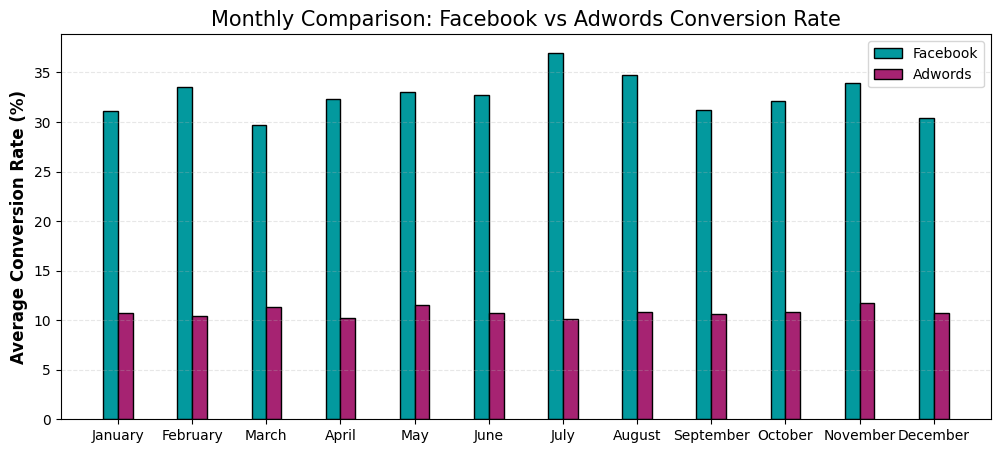

In [34]:

plt.figure(figsize=(12, 5))
x_axis = np.arange(len(month_order))

plt.bar(x_axis - 0.1, monthly_analysis['facebook_conversion_rate'], 0.2, 
        label='Facebook', color='#03999E', edgecolor='black')

plt.bar(x_axis + 0.1, monthly_analysis['adword_conversion_rate'], 0.2, 
        label='Adwords', color='#A62372', edgecolor='black')

plt.xticks(x_axis, month_order)
plt.ylabel('Average Conversion Rate (%)', fontsize=12, fontweight='bold')
plt.title('Monthly Comparison: Facebook vs Adwords Conversion Rate', fontsize=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


In [35]:
# 1. Ensure yearly_analysis is created correctly
yearly_analysis = df.groupby('year')[['facebook_conversion_rate', 'adword_conversion_rate']].mean()


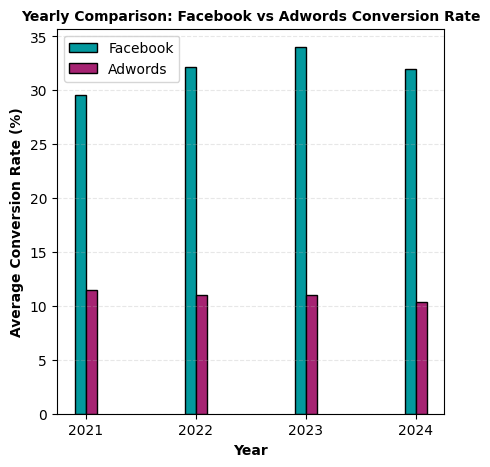

In [36]:

plt.figure(figsize=(5, 5))

# 2. x_axis should be the number of years (usually 3 or 4 years)
x_axis = np.arange(len(yearly_analysis))

# 3. Use yearly_analysis data
plt.bar(x_axis - 0.05, yearly_analysis['facebook_conversion_rate'], 0.1, 
        label='Facebook', color='#03999E', edgecolor='black')

plt.bar(x_axis + 0.05, yearly_analysis['adword_conversion_rate'], 0.1, 
        label='Adwords', color='#A62372', edgecolor='black')

# 4. Set xticks to the Year values (2021, 2022, etc.)
plt.xticks(x_axis, yearly_analysis.index)

plt.ylabel('Average Conversion Rate (%)', fontsize=10, fontweight='bold')
plt.xlabel('Year', fontsize=10, fontweight='bold')
plt.title('Yearly Comparison: Facebook vs Adwords Conversion Rate', fontsize=10, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()